__Group Members__

Aaron Thayravanh, Melissa Unlu, La-Sean Caselberry II

# Group Project: Traffic Prediction

## Initial Data Analysis

In [2]:
import pandas as pd
import numpy as np

In [3]:
traffic_df = pd.read_csv('smart_mobility_dataset.csv')

In [4]:
traffic_df.head()

,Timestamp,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h,Traffic_Condition
0,2024-03-01 00:00:00,40.842275,-73.703149,205,49.893435,82.652780,Yellow,Clear,0,-0.609199,2,45,450.760055,19.574337,High
1,2024-03-01 00:05:00,40.831119,-73.987354,202,22.383965,45.829298,Green,Clear,0,0.965442,16,1,321.800341,5.385554,High
2,2024-03-01 00:10:00,40.819549,-73.732462,252,46.889699,82.772465,Green,Rain,0,0.289660,16,49,231.152655,10.277477,High
3,2024-03-01 00:15:00,40.725849,-73.980134,37,5.730536,37.695567,Red,Fog,0,-0.271965,66,10,410.384292,29.243279,High
4,2024-03-01 00:20:00,40.813265,-73.961631,64,61.348034,22.313358,Red,Snow,0,-0.797606,3,5,364.466342,16.801459,Low


### Checking for missing values

In [5]:
traffic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               5000 non-null   object 
 1   Latitude                5000 non-null   float64
 2   Longitude               5000 non-null   float64
 3   Vehicle_Count           5000 non-null   int64  
 4   Traffic_Speed_kmh       5000 non-null   float64
 5   Road_Occupancy_%        5000 non-null   float64
 6   Traffic_Light_State     5000 non-null   object 
 7   Weather_Condition       5000 non-null   object 
 8   Accident_Report         5000 non-null   int64  
 9   Sentiment_Score         5000 non-null   float64
 10  Ride_Sharing_Demand     5000 non-null   int64  
 11  Parking_Availability    5000 non-null   int64  
 12  Emission_Levels_g_km    5000 non-null   float64
 13  Energy_Consumption_L_h  5000 non-null   float64
 14  Traffic_Condition       5000 non-null   

- No missing values are found within the dataset

### Checking for categorical features

In [6]:
for col in traffic_df.columns:
    print(f'{col}: {len(traffic_df[col].unique())}')

Timestamp: 5000
Latitude: 5000
Longitude: 5000
Vehicle_Count: 290
Traffic_Speed_kmh: 5000
Road_Occupancy_%: 5000
Traffic_Light_State: 3
Weather_Condition: 4
Accident_Report: 2
Sentiment_Score: 5000
Ride_Sharing_Demand: 99
Parking_Availability: 50
Emission_Levels_g_km: 5000
Energy_Consumption_L_h: 5000
Traffic_Condition: 3


- **Traffic_Light_State, Weather_Condition, Accident_Report,** and **Traffic_Conditions** seem like categorical features

#### Converting object data types into integers

In [7]:
print(traffic_df['Traffic_Light_State'].unique())
print(traffic_df['Weather_Condition'].unique())
print(traffic_df['Traffic_Condition'].unique())

['Yellow' 'Green' 'Red']
['Clear' 'Rain' 'Fog' 'Snow']
['High' 'Low' 'Medium']


- **Accident_Report** is already an integer data type so there's no need to change anything

In [8]:
TLS_Map = {'Green': 0, 'Yellow': 1, 'Red': 2}
WC_Map = {'Clear': 0, 'Rain': 1, 'Fog': 2, 'Snow': 3}
TC_Map = {'Low': 0, 'Medium': 1, 'High': 2}

In [9]:
df_f = traffic_df.drop(['Timestamp'], axis=1)
df_f['Traffic_Light_State'] = df_f['Traffic_Light_State'].map(TLS_Map)
df_f['Weather_Condition'] = df_f['Weather_Condition'].map(WC_Map)
df_f['Traffic_Condition'] = df_f['Traffic_Condition'].map(TC_Map)

print(df_f['Traffic_Light_State'].unique())
print(df_f['Weather_Condition'].unique())
print(df_f['Traffic_Condition'].unique())

[1 0 2]
[0 1 2 3]
[2 0 1]


- We map the object classes with a corresponding integer so that we can train the model over these values.
- __Timestamp__ is dropped because it is a arbitrary feature.

In [10]:
df_f.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Latitude                5000 non-null   float64
 1   Longitude               5000 non-null   float64
 2   Vehicle_Count           5000 non-null   int64  
 3   Traffic_Speed_kmh       5000 non-null   float64
 4   Road_Occupancy_%        5000 non-null   float64
 5   Traffic_Light_State     5000 non-null   int64  
 6   Weather_Condition       5000 non-null   int64  
 7   Accident_Report         5000 non-null   int64  
 8   Sentiment_Score         5000 non-null   float64
 9   Ride_Sharing_Demand     5000 non-null   int64  
 10  Parking_Availability    5000 non-null   int64  
 11  Emission_Levels_g_km    5000 non-null   float64
 12  Energy_Consumption_L_h  5000 non-null   float64
 13  Traffic_Condition       5000 non-null   int64  
dtypes: float64(7), int64(7)
memory usage: 54

- As seen the data types are all either __float__ or __int__

### Checking for multicollinearity and highly correlated features

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
from matplotlib import rcParams
rcParams['figure.figsize'] = 15, 5
sns.set_style('darkgrid')

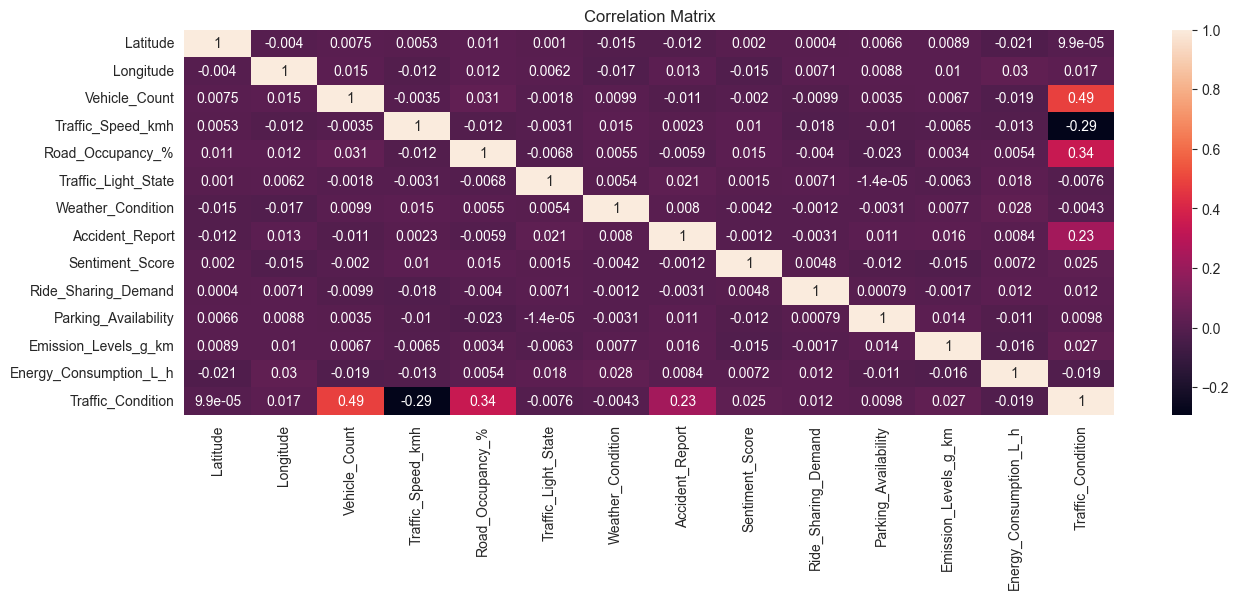

In [13]:
sns.heatmap(df_f.corr(), annot=True)
plt.title('Correlation Matrix')
plt.show()

- As seen in the correlation matrix, none of the features, other than the target, are highly correlated with each other. This means that multicollinearity is most likely not a issue.
- It seems that the features **Vehicle_Count, Traffic_Speed_kmh, Road_Occupancy_%,** and **Accident_Report** are highly correlated with our target, **Traffic_Condition**.

## Creating the Model

### Preparing data for training

In [14]:
X = df_f[[
    'Vehicle_Count',
    'Traffic_Speed_kmh',
    'Road_Occupancy_%',
    'Traffic_Light_State',
    'Accident_Report'
]].copy()

y = df_f['Traffic_Condition']

- We put the features found via our correlation matrix is put into __X__
- We want to predict **Traffic_Condition** so we set it as our __target__

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

- Scaling the data to improve performance and ensure model stability

### Model training and creation

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.3,
    random_state=0
)

In [17]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(128,64,32,16),
    max_iter=500,
    activation='relu',
    random_state=0
)

mlp.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(128, 64, 32, 16), max_iter=500,
              random_state=0)

## Model Results

In [18]:
predictions = mlp.predict(X_test)

- Our model prediction

### Classification Report and Confusion Matrix

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       107
           1       0.96      0.98      0.97       441
           2       1.00      0.99      0.99       952

    accuracy                           0.98      1500
   macro avg       0.97      0.98      0.98      1500
weighted avg       0.98      0.98      0.98      1500



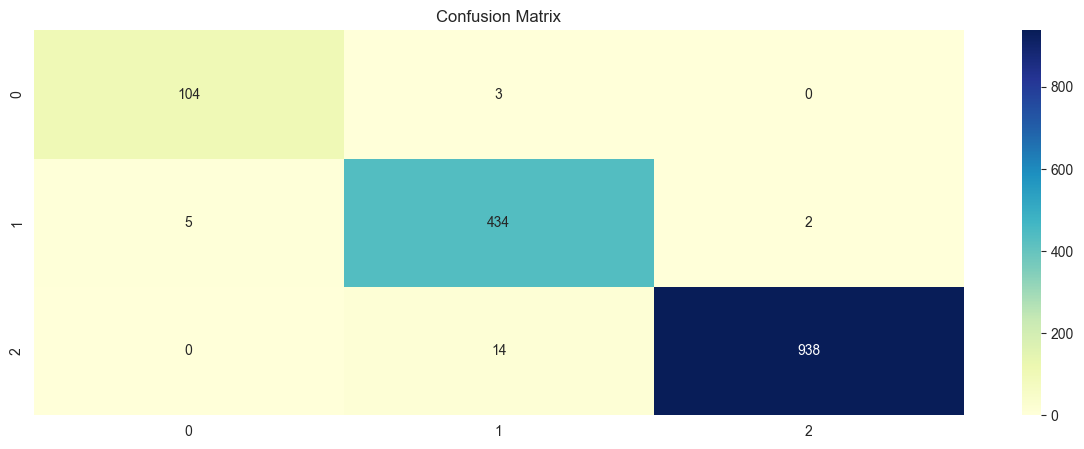

In [72]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test,predictions))
sns.heatmap(confusion_matrix(y_test,predictions), cmap='YlGnBu', annot=True, fmt='g')
plt.title('Confusion Matrix')
plt.show()

- __0, 1, 2__ corresponds to __low, medium, high__ for traffic conditions
- Overall our model seemed to have performed well with very high metrics all around

### Training Loss

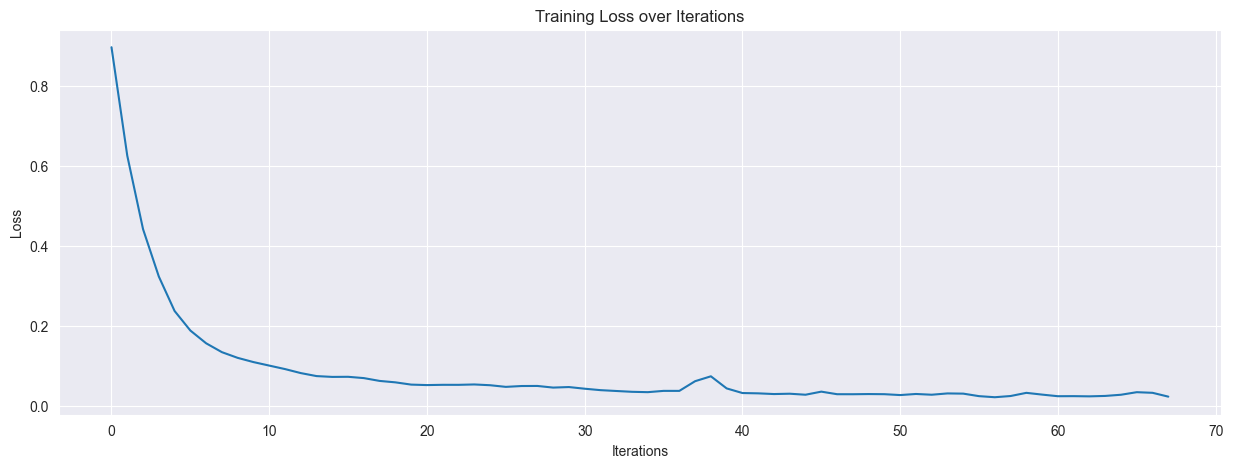

In [41]:
plt.plot(mlp.loss_curve_)
plt.title('Training Loss over Iterations')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.show()

- Training loss over the intial iterations significantly drops off and then gradually flattens over the preceeding iterations

### Checking for overfitting or underfitting

In [98]:
train_score = mlp.score(X_train, y_train)
test_score = mlp.score(X_test, y_test)

print(f'Train Accuracy: {train_score}')
print(f'Test Accuracy: {test_score}')
print(f'Difference: {abs(train_score-test_score)}')

Train Accuracy: 0.9922857142857143
Test Accuracy: 0.984
Difference: 0.00828571428571434


- The train and test accuracies are very close to each with only ~0.8 difference.
- Both accuracies are relatively high too.
- This means that there is no significant overfitting or underfitting with the model.

- If there was overfitting or underfitting these are some ways to to reduce it:
    - Increase or simplify model complexity
        - Reduce/increase the number of hidden layers or neurons
        - Use a smaller or larger model
    - Add or reduce regularization
    - Train for more iterations
    - Add more training data
    - Modify data or remove/add certain features

### Ablation studies

#### Preparing different parameters for hyperparameter tuning

In [113]:
layer_configs = [
    (128, 64, 32, 16),   # Baseline
    (64, 32),            # Fewer layers
    (256, 128, 64, 32),  # More Layers
    (128, 64, 32, 16),   # Baseline but will introduce higher regularization
    (128, 64, 32, 16)    # Baseline but will introduce more iterations
]

# Every alpha will be default except for one
alpha_configs = [
    0.0001,
    0.0001,
    0.0001,
    0.01,
    0.0001
]

# Every amount of iterations will be the same except for one
iter_configs = [
    500,
    500,
    500,
    500,
    1000
]

#### Experimenting on these parameters

In [134]:
from sklearn.model_selection import KFold, cross_val_score

for la, alp, it in zip(layer_configs, alpha_configs, iter_configs):
    mlp = MLPClassifier(
        hidden_layer_sizes=la,
        alpha=alp,
        max_iter=it,
        activation='relu',
        random_state=0
    )

    kf = KFold(n_splits=10, shuffle=True, random_state=0)
    train_scores = cross_val_score(mlp, X_train, y_train, cv=kf, scoring='accuracy')
    
    mlp.fit(X_train, y_train)
    test_score = mlp.score(X_test, y_test)
    
    print(f'Hidden Layer Sizes: {la}, Alpha: {alp}, Max Iter: {it}')
    print(f'Average Train Accuracy: {train_scores.mean()}')
    print(f'Test Accuracy: {test_score}')
    print()

Hidden Layer Sizes: (128, 64, 32, 16), Alpha: 0.0001, Max Iter: 500
Average Train Accuracy: 0.9788571428571429
Test Accuracy: 0.984

Hidden Layer Sizes: (64, 32), Alpha: 0.0001, Max Iter: 500
Average Train Accuracy: 0.9845714285714287
Test Accuracy: 0.99

Hidden Layer Sizes: (256, 128, 64, 32), Alpha: 0.0001, Max Iter: 500
Average Train Accuracy: 0.9774285714285714
Test Accuracy: 0.982

Hidden Layer Sizes: (128, 64, 32, 16), Alpha: 0.01, Max Iter: 500
Average Train Accuracy: 0.980857142857143
Test Accuracy: 0.9846666666666667

Hidden Layer Sizes: (128, 64, 32, 16), Alpha: 0.0001, Max Iter: 1000
Average Train Accuracy: 0.9788571428571429
Test Accuracy: 0.984



- __1st Output: Baseline__
    - Balanced performance
    - Average train accuracy is slighltly lower than test accuracy.

- __2nd Output: Fewer Layers__
    - Best generalization
    - Achieves high test accuracy with strong train performance.

- __3rd Output: More Layers__
    - Slight underfitting compared to the original baseline
    - Train and test accuracy dropped slightly. More layers did not help the model.

- __4th Output: Higher Regularization (alpha)__
    - Better generalization with regularization
    - Slightly improved generalization without hurting train and test accuracy

- __5th Output: More iterations__
    - No significant gains with more iterations
    - Meaning 500 iterations were already enough

#### Hyperparameter Tuning

In [139]:
from sklearn.model_selection import GridSearchCV

params = {
    'hidden_layer_sizes': layer_configs,
    'alpha': alpha_configs,
    'max_iter': iter_configs,
    'activation': ['relu'],
    'random_state': [0]
}

mlp = MLPClassifier()

grid_search = GridSearchCV(
    estimator=mlp,
    param_grid=params,
    scoring='accuracy',
    cv=5,
    verbose=2
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 125 candidates, totalling 625 fits
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(128, 64, 32, 16), max_iter=500, random_state=0; total time=   2.3s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(128, 64, 32, 16), max_iter=500, random_state=0; total time=   2.2s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(128, 64, 32, 16), max_iter=500, random_state=0; total time=   3.5s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(128, 64, 32, 16), max_iter=500, random_state=0; total time=   2.2s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(128, 64, 32, 16), max_iter=500, random_state=0; total time=   2.0s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(128, 64, 32, 16), max_iter=500, random_state=0; total time=   2.1s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(128, 64, 32, 16), max_iter=500, random_state=0; total time=   2.5s
[CV] END activation=relu, alpha=0.0001, hidden_l

GridSearchCV(cv=5, estimator=MLPClassifier(),
             param_grid={'activation': ['relu'],
                         'alpha': [0.0001, 0.0001, 0.0001, 0.01, 0.0001],
                         'hidden_layer_sizes': [(128, 64, 32, 16), (64, 32),
                                                (256, 128, 64, 32),
                                                (128, 64, 32, 16),
                                                (128, 64, 32, 16)],
                         'max_iter': [500, 500, 500, 500, 1000],
                         'random_state': [0]},
             scoring='accuracy', verbose=2)

#### Best Parameters

In [142]:
grid_search.best_params_

{'activation': 'relu',
 'alpha': 0.0001,
 'hidden_layer_sizes': (64, 32),
 'max_iter': 500,
 'random_state': 0}

#### Recreating model with best parameters

In [150]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    alpha=0.0001,
    max_iter=500,
    activation='relu',
    random_state=0
)

mlp.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=0)

In [152]:
new_pred = mlp.predict(X_test)

##### New Classification Report and Confusion Matrix

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       107
           1       0.98      0.98      0.98       441
           2       0.99      0.99      0.99       952

    accuracy                           0.99      1500
   macro avg       0.99      0.98      0.99      1500
weighted avg       0.99      0.99      0.99      1500



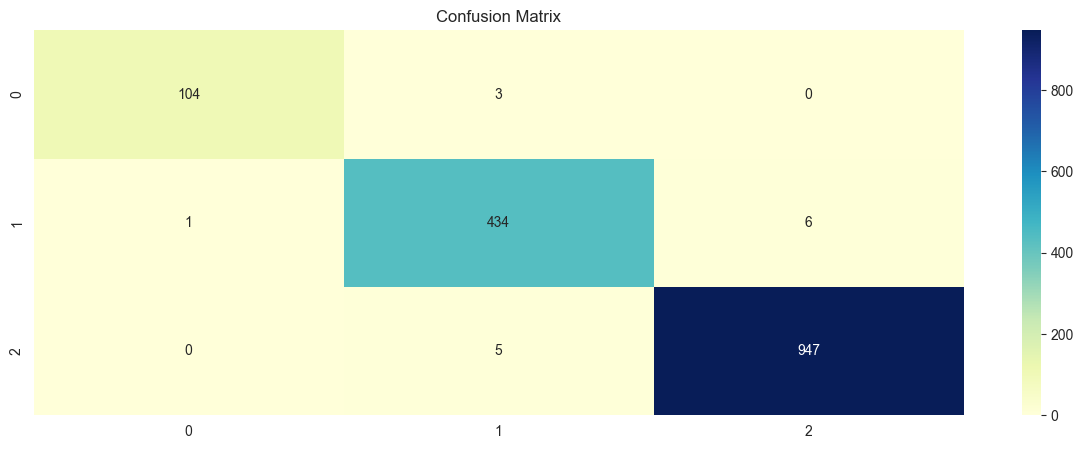

In [154]:
print(classification_report(y_test,new_pred))
sns.heatmap(confusion_matrix(y_test,new_pred), cmap='YlGnBu', annot=True, fmt='g')
plt.title('Confusion Matrix')
plt.show()

- After tuning and rebuilding the model, performance seems to be much better, with less false predictions

##### New Training Loss

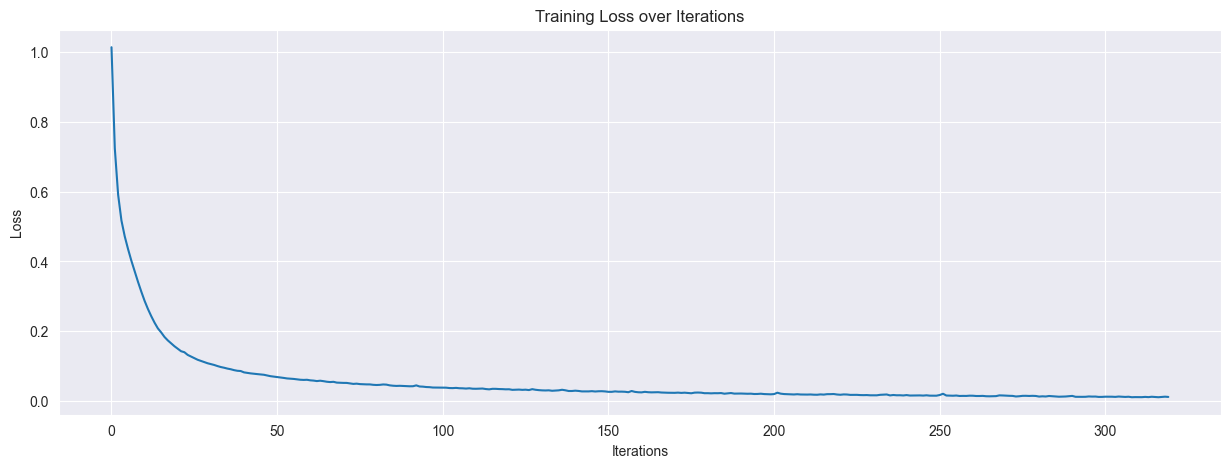

In [156]:
plt.plot(mlp.loss_curve_)
plt.title('Training Loss over Iterations')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.show()

- The training loss curve over the iterations seems to be much better with a smoother curve.

### Computational complextity analysis

In [174]:
print(f'Input feature size: {X_train.shape[1]}')
print(f'Output classes: {len(y_train.unique())}')
print(f'Training set size: {X_train.shape[0]}')
print(f'Number of Iterations: {500}')

Input feature size: 5
Output classes: 3
Training set size: 3500
Number of Iterations: 500


In [176]:
print(f'Layer sizes including hidden layers: {'[5, 64, 32, 3]'}')

Layer sizes including hidden layers: [5, 64, 32, 3]
